<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/main/03c_visualizations_net_change.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing

In [ ]:

import pandas as pd
import geopandas as gpd
import numpy as np
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import plotly.express as px
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')


#uncomment on first run
!wget https://raw.githubusercontent.com/miaflynn/CYPLAN255-Final-Project/main/functions.py
import functions as fx

import importlib
importlib.reload(fx)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--2026-04-13 01:42:41--  https://raw.githubusercontent.com/miaflynn/CYPLAN255-Final-Project/main/functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8682 (8.5K) [text/plain]
Saving to: ‘functions.py.1’

functions.py.1      100%[===================>]   8.48K  --.-KB/s    in 0s      

2026-04-13 01:42:41 (67.8 MB/s) - ‘functions.py.1’ saved [8682/8682]



<module 'functions' from '/content/functions.py'>

##Reading in file

In [ ]:
#gdf of opening dates after 2016 concatenated with gdf of closing dates after 2016
gdf_open_close = gpd.read_file("/content/drive/MyDrive/C255_final_project/cleaned/open_close_after_2016.geojson")

#all businesses with no end date or end dates after 2016
gdf_biz = gpd.read_file("/content/drive/MyDrive/C255_final_project/cleaned/biz_all_startdate.geojson")

#immediately clipping to exclude openings in 2026
gdf_biz = gdf_biz[(gdf_biz.year_open <=2025)]

##Reading in census tracts and block groups

In [ ]:
sf_tracts = gpd.read_file('/content/drive/MyDrive/C255_final_project/cleaned/sf_tracts.geojson')

sf_block_grp = gpd.read_file('/content/drive/MyDrive/C255_final_project/cleaned/sf_block_grp.geojson')

##Do i want to filter to a specific naics code or collection of codes?

In [ ]:
naics_dict = {

    'Information': '5100-5199',
    'Financial Services': '5210-5239',
    'Accommodations': '7210-7219',
    'Retail Trade': '4400-4599',
    'Construction': '2300-2399',
    'Food Services': '7220-7229',
    'Manufacturing': '3100-3399',
    'Real Estate and Rental and Leasing Services': '5300-5399',
    'Arts, Entertainment, and Recreation': '7100-7199',
    'Private Education and Health Services': '6100-6299',
    'Administrative and Support Services': '5600-5699',
    'Professional, Scientific, and Technical Services': '5400-5499',
    'Certain Services': '8100-8139',
    'Wholesale Trade': '4200-4299',
    'Transportation and Warehousing': '4800-4999',
    'Insurance': '5240-5249',
    'Utilities': '2200-2299',

    #special categories
    'Retail, Food and Arts/Entertainment':'7220-7229|4400-4599|7100-7199'

}

#------------------------Desired cateogry--------------------------
naics_name = 'all'
#naics_name = 'Retail, Food and Arts/Entertainment'
#------------------------------------------------------------------


In [ ]:
open_close_tracts_gdf = fx.calc_business_dynamics(
    gdf_open_close,
    gdf_biz,
    sf_tracts,
    naics_name
)

open_close_grp_gdf = fx.calc_business_dynamics(
    gdf_open_close,
    gdf_biz,
    sf_block_grp,
    naics_name
)

##getting epc tracts and adding is_epc boolean

In [ ]:
epc_tracts = gpd.read_file("/content/drive/MyDrive/C255_final_project/cleaned/epc_tracts_sf.geojson")
epc_tracts = epc_tracts.rename(columns={'tract_geoid': 'GEOID'})

open_close_tracts_gdf['is_epc'] = open_close_tracts_gdf['GEOID'].isin(epc_tracts['GEOID'])

#Choropleth maps

###Net entry rate map (net change for year / total businesses active that year)

In [ ]:
#commenting out for github

# #block grp
# fx.choropleth_animated(
#     open_close_grp_gdf, 'net_entry_rate', epc_tracts
# )

# #tract level
# fx.choropleth_animated(
#     open_close_tracts_gdf, 'net_entry_rate', epc_tracts
# )


###Map of percent change in businesses compared to 2016 (net change each year / baseline net change in 2016)

In [ ]:
# #block group
# fx.choropleth_animated(
#     open_close_grp_gdf, 'growth_pct_over_2016', epc_tracts, 2017
# )

# #tract level
# fx.choropleth_animated(
#     open_close_tracts_gdf, 'growth_pct_over_2016', epc_tracts, 2017
# )

#EPC Line Graph

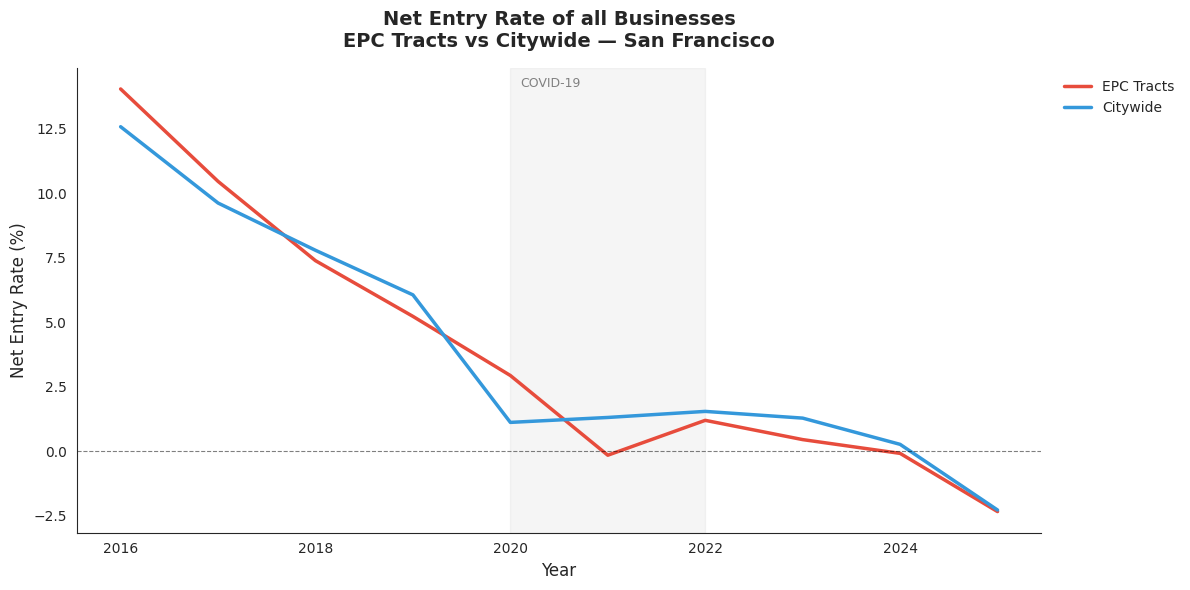

In [ ]:
citywide_avg = open_close_tracts_gdf.groupby('year').agg(
    net_change=('net_change', 'sum'),
    biz_stock=('biz_stock', 'sum')
).reset_index()
citywide_avg['net_entry_rate'] = (citywide_avg['net_change'] / citywide_avg['biz_stock']) * 100
citywide_avg['comparison'] = 'Citywide'

epc_only = open_close_tracts_gdf[open_close_tracts_gdf['is_epc']].copy()
epc_only['comparison'] = 'EPC Tracts'

plot_df = pd.concat([epc_only, citywide_avg]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

sns.set_style('white')
sns.lineplot(
    plot_df,
    x='year',
    y='net_entry_rate',
    hue='comparison',
    estimator='mean',
    errorbar=None,
    linewidth=2.5,
    palette={'EPC Tracts': '#e74c3c', 'Citywide': '#3498db'},
    ax=ax
)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvspan(2020, 2022, alpha=0.08, color='gray')
ax.text(2020.1, ax.get_ylim()[1] * 0.95, 'COVID-19', fontsize=9, color='gray')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Net Entry Rate (%)', fontsize=12)
ax.set_title(f'Net Entry Rate of {naics_name} Businesses\nEPC Tracts vs Citywide — San Francisco',
             fontsize=14, fontweight='bold', pad=15)

ax.legend(title=None, bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

#Across industries EPC analysis

In [ ]:
#naics code names to compare - top ten types of businesses
naics_to_compare = ['Food Services',
                    'Retail Trade',
                    'Arts, Entertainment, and Recreation',
                    'Accommodations',
                    'Financial Services',
                    'Private Education and Health Services',
                    'Professional, Scientific, and Technical Services',
                    'Real Estate and Rental and Leasing Services',
                    'Construction',
                    'Financial Services'
]

dfs = []
for name in naics_to_compare:
    result = fx.calc_business_dynamics(gdf_open_close, gdf_biz, sf_tracts, naics_name=name)
    result['naics_name'] = name
    dfs.append(result)

combined = pd.concat(dfs).reset_index()

combined['is_epc'] = combined['GEOID'].isin(epc_tracts['GEOID'])

#look here to see metric options
combined.columns

Index(['index', 'GEOID', 'geometry', 'year', 'closed', 'opened',
       'naics_filter', 'net_change', 'baseline_2016', 'growth_pct_over_2016',
       'biz_stock', 'net_entry_rate', 'gross_exit_rate', 'total_activity',
       'naics_name', 'is_epc'],
      dtype='object')

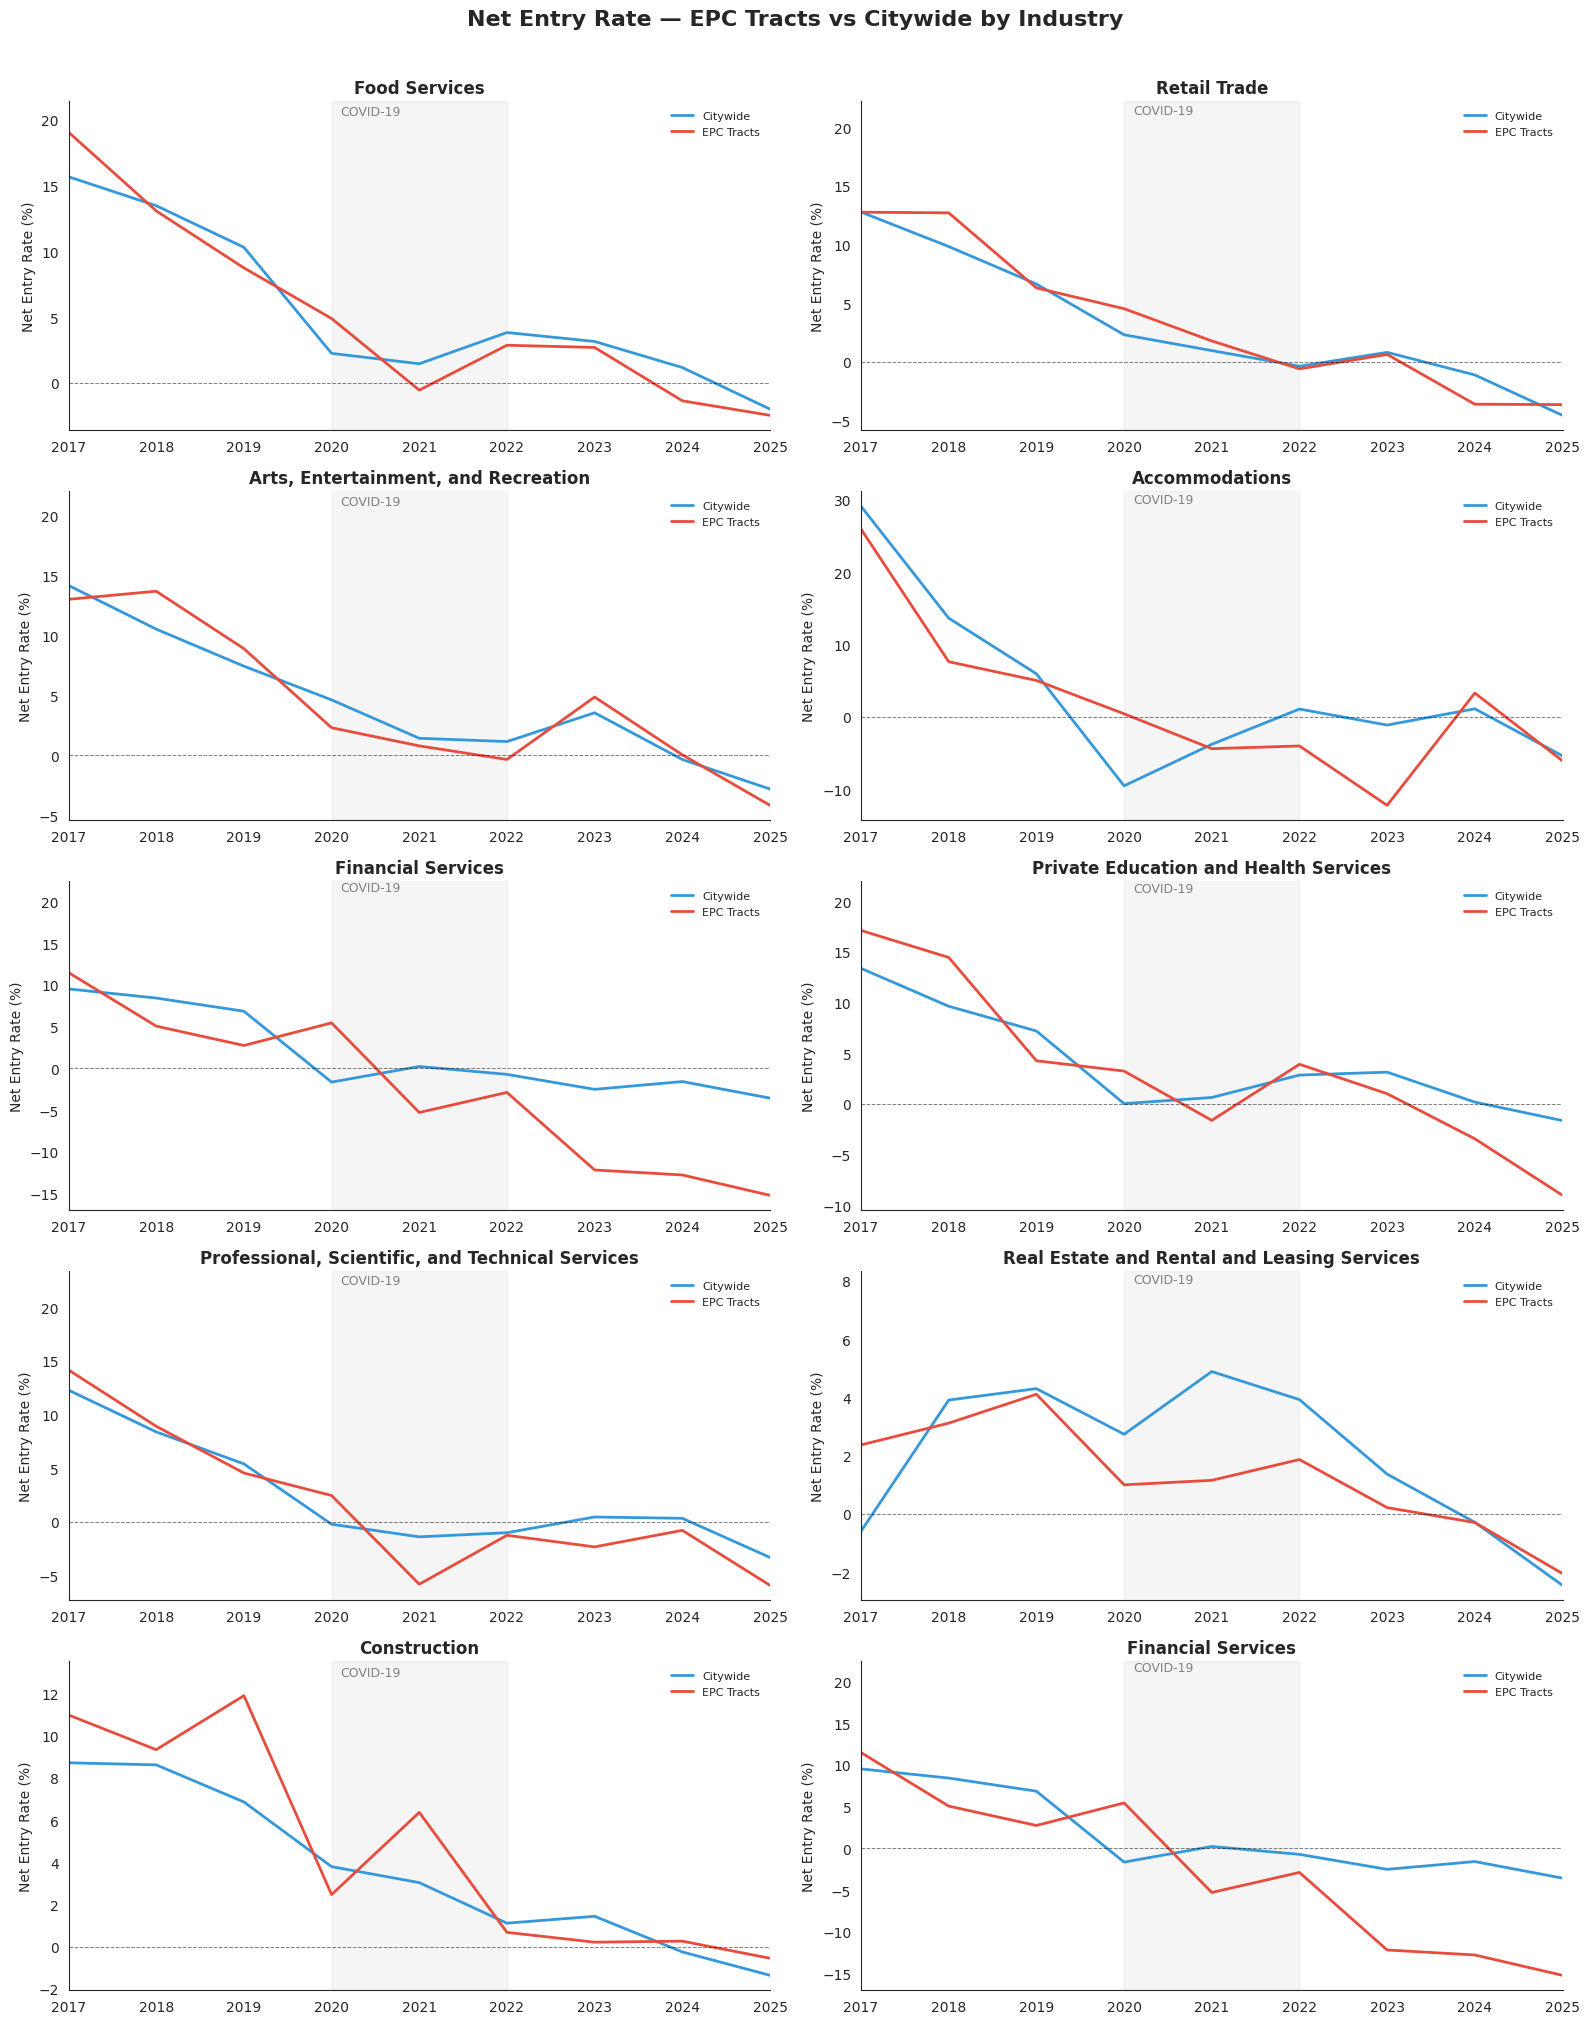

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, name in enumerate(naics_to_compare):
    ax = axes[i]

    citywide = combined[combined['naics_name'] == name].groupby('year').agg(
        net_change=('net_change', 'sum'),
        biz_stock=('biz_stock', 'sum')
    ).reset_index()

    citywide['net_entry_rate'] = (citywide['net_change'] / citywide['biz_stock']) * 100
    citywide['comparison'] = 'Citywide'

    epc = combined[(combined['naics_name'] == name) & (combined['is_epc'])].copy()
    epc['comparison'] = 'EPC Tracts'

    plot_df = pd.concat([citywide, epc]).reset_index(drop=True)

    sns.lineplot(
        plot_df,
        x='year',
        y='net_entry_rate',
        hue='comparison',
        estimator='mean',
        errorbar=None,
        linewidth=2,
        palette={'EPC Tracts': '#e74c3c', 'Citywide': '#3498db'},
        ax=ax
    )

    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.axvspan(2020, 2022, alpha=0.08, color='gray')
    ax.text(2020.1, ax.get_ylim()[1] * 0.95, 'COVID-19', fontsize=9, color='gray')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Net Entry Rate (%)')
    ax.set_xlim(2017, 2025)
    ax.legend(title=None, frameon=False, fontsize=8)

fig.suptitle('Net Entry Rate — EPC Tracts vs Citywide by Industry', fontsize=16, fontweight='bold', y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

#Across industries line graph using average of all point data

In [ ]:
# group by year and naics
citywide_by_naics = (
    gdf_open_close
    .groupby(['year', 'naics_code_description', 'status'])
    .size()
    .reset_index(name='count')
    .pivot(index=['year', 'naics_code_description'], columns='status', values='count')
    .fillna(0)
    .reset_index()
)

citywide_by_naics['net_change'] = citywide_by_naics['opened'] - citywide_by_naics['closed']

#filtering
citywide_by_naics = citywide_by_naics[citywide_by_naics['naics_code_description'].isin(naics_to_compare)]



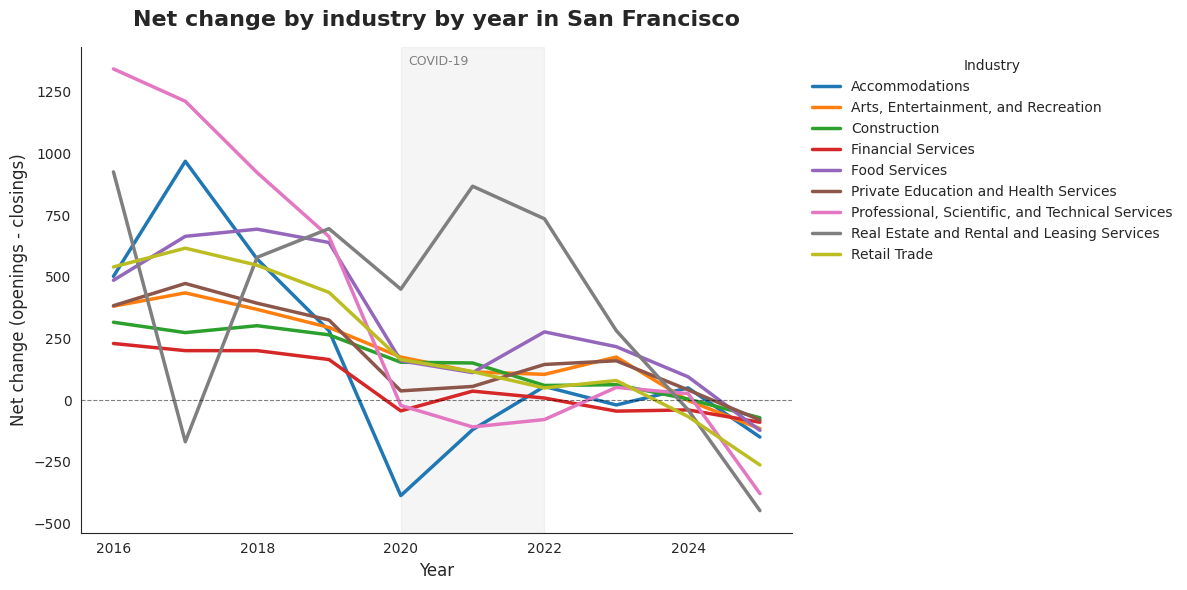

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.set_style('white')
sns.lineplot(
    citywide_by_naics,
    x='year',
    y='net_change',
    hue='naics_code_description',
    errorbar=None,
    estimator='mean',
    linewidth=2.5,
    ax=ax
)

# adds the zero line
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# adds labels on axes and sets new title with styling
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Net change (openings - closings)', fontsize=12)
ax.set_title('Net change by industry by year in San Francisco', fontsize=16, fontweight='bold', pad=15)

# legend moved
ax.legend(title='Industry', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

# adds the covid styling
ax.axvspan(2020, 2022, alpha=0.08, color='gray', label='COVID-19 Pandemic')
ax.text(2020.1, ax.get_ylim()[1] * 0.95, 'COVID-19', fontsize=9, color='gray')

sns.despine()
plt.tight_layout()
plt.show()